In [2]:
import json
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from cmdstanpy import CmdStanVB

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def calculate_eta(vi, wi, theta, V):
    rho_v = theta[vi, :]          # ρ_v = θ_v
    alpha_w = theta[wi + V, :]    # α_w = θ_{V + w}
    eta = rho_v.dot(alpha_w)      # η = ρ_v^T α_w
    return sigmoid(eta)

def extract_correlation(word1, word2, vocabulary, theta_samples):
    vi = vocabulary[word1]
    wi = vocabulary[word2]
    V = len(vocabulary)

    p_samples = []
    for theta in theta_samples:
        eta = calculate_eta(vi, wi, theta, V)
        p_samples.append(eta)

    return np.array(p_samples)

def credible_interval(samples, confidence=0.90):
    lower_bound = np.percentile(samples, (1-confidence)/ 2 * 100)
    upper_bound = np.percentile(samples, (1+confidence)/ 2 * 100)
    return lower_bound, upper_bound

def load_fit(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

def calculate_true_correlation(word1, word2, vocabulary, true_theta):
    vi = vocabulary[word1]
    wi = vocabulary[word2]
    V = len(vocabulary)
    eta = calculate_eta(vi, wi, true_theta, V)
    return eta

def extract_word_and_context_vectors(variational_params, vocabulary, D=2): # TODO REMOVE
    """
    Extracts the word and context vectors from the draws
    """
    # exclude the first 2 columns (lp__, log_p__,
    relevant_params = variational_params[:, 2:]
    
    num_samples = relevant_params.shape[0]
    word_vectors = np.zeros((num_samples, len(vocabulary), D))
    context_vectors = np.zeros((num_samples, len(vocabulary), D))
    
    for d in range(D):
        for n in range(len(vocabulary)):
            word_vectors[:, n, d] = relevant_params[:, n + d * len(vocabulary)]
            context_vectors[:, n, d] = relevant_params[:, len(vocabulary) * D + n + d * len(vocabulary)]
    
    return word_vectors, context_vectors

def plot_posterior(word_index, word_vectors_samples, vocabulary):
    word_samples = word_vectors_samples[:, word_index, :]

    # For seaborn..
    data = {
        'Dim 1': word_samples[:, 0],
        'Dim 2': word_samples[:, 1],
    }
    df = pd.DataFrame(data)

    plt.figure(figsize=(10, 6))
    sns.jointplot(x='Dim 1', y='Dim 2', data=df, kind='kde', fill=True)
    
    plt.suptitle(f"Posterior samples for  '{list(vocabulary.keys())[word_index]}'", y=1.02)
    plt.scatter([np.mean(word_samples[:, 0])] , [np.mean(word_samples[:, 1])] , marker ='x', color='tab:red')
    plt.axhline(y=0, color='tab:gray', ls='--')
    plt.axvline(x=0, color='tab:gray', ls='--')
    plt.show()


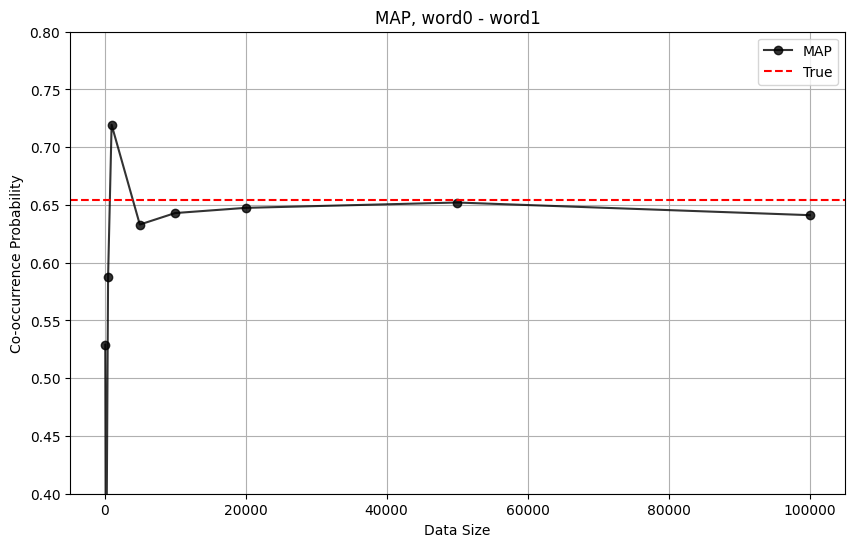

In [10]:

with open('100k_v10_d2_.json') as f:
    data = json.load(f)

true_theta = np.array(data['theta'])
vocabulary = data['vocabulary']

# Dir where fits are saved
output_dir = "stan_fits_map"

sizes = [100, 200, 500, 1000, 5000, 10000, 20000, 50000, 100000]

# Words to compare
word1 = "word0"
word2 = "word1"


true_correlation = calculate_true_correlation(word1, word2, vocabulary, true_theta)

correlations = []
credible_intervals = []

for size in sizes:
    # --- MAP ----
    map_filename = os.path.join(output_dir, f'stan_fit_{size}.pkl')

    with open(map_filename, 'rb') as f:
        map = pickle.load(f)

    map_params = map.stan_variables()
    map_theta = np.vstack((map_params['word_vectors'], map_params['context_vectors']))
    map_corr = calculate_true_correlation(word1, word2, vocabulary, map_theta)  #todo "true correlation" is not quite right here. But its the same function ofc.
    # -----
    
    correlations.append(map_corr)
    #mean_corr = np.mean(eta_samples)


correlations = np.array(correlations)

plt.figure(figsize=(10, 6))
plt.ylim([0.4, 0.8])
plt.plot(sizes, correlations, marker='o', linestyle='-', label='MAP', color='black', alpha=0.8)
#plt.fill_between(sizes, credible_intervals[:, 0], credible_intervals[:, 1], color='tab:orange', alpha=0.2, label='Laplace 90% CI')
plt.axhline(y=true_correlation, color='r', linestyle='--', label='True')
plt.xlabel('Data Size')
plt.ylabel('Co-occurrence Probability')
plt.title('MAP, %s - %s'%(word1, word2))
plt.legend()
plt.grid(True)
plt.show()



<Figure size 1000x600 with 0 Axes>

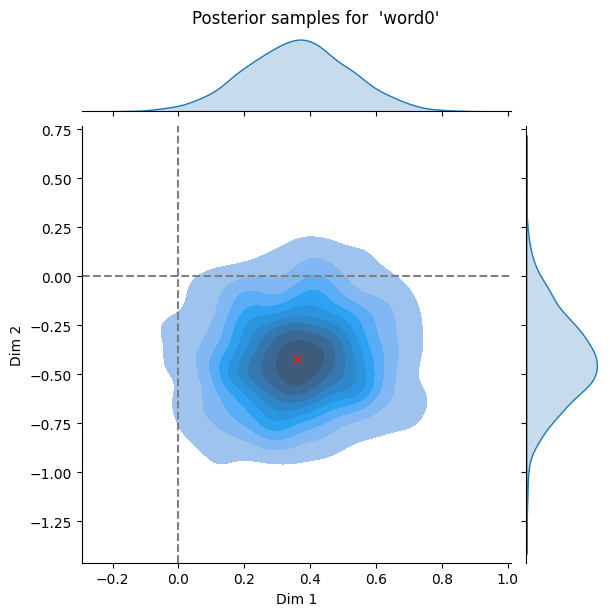

In [55]:
word_index = 0
plot_posterior(word_index, word_vectors, vocabulary)